## 0) Variable meanings

This notebook predicts whether the center pixel will be burning one hour ahead, then evaluates threshold-based classification quality.

- **Prediction target**: center-cell GOES fire confidence at `t+1`, converted to binary.
- **Positive class (`1`)**: `confidence_t+1 >= POSITIVE_THRESHOLD`.
- **Negative class (`0`)**: `confidence_t+1 < POSITIVE_THRESHOLD`.
- **Spatial context**: center + 8 neighbors (`C, NW, N, NE, W, E, SW, S, SE`).
- **Per-cell features**:
  - `fire_confidence` (GOES confidence at hour `t`)
  - `temperature` (RTMA `TMP`)
  - `wind_speed` (RTMA `WIND`)
  - `specific_humidity` (RTMA `SPFH`)
  - `precipitation_1h` (RTMA `ACPC01`)
  - `discounted_rain_30d` (discounted trailing 30-day RTMA precipitation)
  - `wind_direction_sin` and `wind_direction_cos` (cyclic encoding of RTMA `WDIR`)
- **Model**: feed-forward neural network trained in PyTorch with weighted binary cross-entropy.
- **Evaluation style**: fire-level holdout (train and test use disjoint fires).


## 1) Summary

This notebook is organized as a full, end-to-end baseline pipeline.

- Discover and split fire events into train/test at the **fire level**.
- Build pixel-level supervised samples from GOES + RTMA at aligned hours.
- Optionally normalize features using **train-only** statistics.
- Train a feed-forward neural network on train fires only.
- Evaluate with:
  - fixed threshold metrics on test data,
  - validation PR sweep (for threshold selection),
  - optional train-selected-threshold transfer to test,
  - test PR curve and top-F1 thresholds.
- Export summary tables and a JSON-style report payload.


## 2) Section toggles

You can run the notebook section-by-section using boolean toggles in the config cell.

- `RUN_FIRE_DISCOVERY_SECTION`: load fire manifests and split into train/test fires.
- `RUN_DATA_STATS_SECTION`: count total/train/test samples and class balance.
- `RUN_NORMALIZATION_SECTION`: compute z-score normalization stats on train data.
- `RUN_TRAINING_SECTION`: train the feed-forward neural network.
- `RUN_EVALUATION_SECTION`: evaluate fixed-threshold metrics on held-out test fires.
- `RUN_SUMMARY_SECTION`: build tabular result summaries.
- `RUN_PR_SECTION`: run threshold sweeps / precision-recall analyses.
- `RUN_COEFFICIENT_SECTION`: show the documented placeholder for coefficient-style interpretation.
- `RUN_REPORT_SECTION`: assemble the final report dictionary.

Dependencies:
- Training depends on discovery (+ normalization if enabled).
- Evaluation/PR/report depend on a trained model.


In [1]:
# Cell purpose:
# Define all high-impact run configuration knobs for this notebook.
#
# Notes:
# - Train/test split is fire-level, not row-level.
# - POSITIVE_THRESHOLD defines the label (ground-truth) binarization rule.
# - CLASSIFICATION_PROB_THRESHOLD defines inference-time probability cutoff.
# - Section toggles let you run the pipeline incrementally.

from pathlib import Path

# Fire selection:
# - "all" => use every fire in data/multi_fire/*
# - list => use only named fires, e.g. ["Creek", "Dixie"]
FIRE_SELECTION = "all"

# Fire-level train/test split settings.
# - If TRAIN_FIRES and TEST_FIRES are both "auto": split selected fires by FIRE_TRAIN_FRACTION
# - If one side is "auto" and the other is a list: auto side gets remaining fires
# - If both are lists: both lists are used exactly
TRAIN_FIRES = "auto"
TEST_FIRES = "auto"
FIRE_TRAIN_FRACTION = 0.70
FIRE_SPLIT_SEED = 42

# Classification settings.
POSITIVE_THRESHOLD = 0.10
CLASSIFICATION_PROB_THRESHOLD = 0.50

# Feature scaling settings.
NORMALIZE_FEATURES = True

# Feature engineering settings.
INCLUDE_DISCOUNTED_RAIN_FEATURE = True
DISCOUNTED_RAIN_LOOKBACK_HOURS = 24 * 30
DISCOUNTED_RAIN_HALF_LIFE_DAYS = 7.0

# Neural-network settings.
SEED = 1337
EPOCHS = 3
BATCH_SIZE = 8192
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
HIDDEN_DIMS = [256, 128, 64]
DROPOUT = 0.3
USE_BATCHNORM = True

# Section toggles.
RUN_FIRE_DISCOVERY_SECTION = True
RUN_DATA_STATS_SECTION = True
RUN_NORMALIZATION_SECTION = True
RUN_TRAINING_SECTION = True
RUN_EVALUATION_SECTION = True
RUN_SUMMARY_SECTION = True
RUN_PR_SECTION = True
RUN_COEFFICIENT_SECTION = True
RUN_REPORT_SECTION = True


In [2]:
# Cell purpose:
# Echo the active configuration so each run has an explicit, auditable context.
# This is useful when comparing runs with different thresholds or split seeds.

print("cwd:", Path.cwd())
print("fire selection:", FIRE_SELECTION)
print("train fires config:", TRAIN_FIRES)
print("test fires config:", TEST_FIRES)
print("fire train fraction (auto mode):", FIRE_TRAIN_FRACTION)
print("fire split seed:", FIRE_SPLIT_SEED)
print("positive confidence threshold:", POSITIVE_THRESHOLD)
print("classification probability threshold:", CLASSIFICATION_PROB_THRESHOLD)
print("normalize features:", NORMALIZE_FEATURES)
print("include discounted rain feature:", INCLUDE_DISCOUNTED_RAIN_FEATURE)
print("discounted rain lookback hours:", DISCOUNTED_RAIN_LOOKBACK_HOURS)
print("discounted rain half-life days:", DISCOUNTED_RAIN_HALF_LIFE_DAYS)
print("seed:", SEED)
print("epochs:", EPOCHS)
print("batch size:", BATCH_SIZE)
print("learning rate:", LEARNING_RATE)
print("weight decay:", WEIGHT_DECAY)
print("hidden dims:", HIDDEN_DIMS)
print("dropout:", DROPOUT)
print("use batchnorm:", USE_BATCHNORM)
print("section toggles:")
print("  fire discovery:", RUN_FIRE_DISCOVERY_SECTION)
print("  data stats:", RUN_DATA_STATS_SECTION)
print("  normalization:", RUN_NORMALIZATION_SECTION)
print("  training:", RUN_TRAINING_SECTION)
print("  evaluation:", RUN_EVALUATION_SECTION)
print("  summary:", RUN_SUMMARY_SECTION)
print("  precision-recall:", RUN_PR_SECTION)
print("  coefficients placeholder:", RUN_COEFFICIENT_SECTION)
print("  report:", RUN_REPORT_SECTION)


cwd: /Users/seanmay/Desktop/Current Projects/wildfire-prediction/docs
fire selection: all
train fires config: auto
test fires config: auto
fire train fraction (auto mode): 0.7
fire split seed: 42
positive confidence threshold: 0.1
classification probability threshold: 0.5
normalize features: True
include discounted rain feature: True
discounted rain lookback hours: 720
discounted rain half-life days: 7.0
seed: 1337
epochs: 3
batch size: 8192
learning rate: 0.001
weight decay: 0.0001
hidden dims: [256, 128, 64]
dropout: 0.3
use batchnorm: True
section toggles:
  fire discovery: True
  data stats: True
  normalization: True
  training: True
  evaluation: True
  summary: True
  precision-recall: True
  coefficients placeholder: True
  report: True


## 3) Imports and generic helpers

This section loads all required libraries and defines small, reusable helper utilities used throughout the notebook.


In [3]:
# Cell purpose:
# Import plotting/data dependencies and the shared pipeline helpers.

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

cwd = Path.cwd().resolve()
for candidate in [cwd] + list(cwd.parents):
    if (candidate / "scripts").exists() and (candidate / "docs").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError("Could not find repo root to import shared notebook helpers.")

from scripts.neighbor_cell_logreg import (
    CELL_OFFSETS,
    DISCOUNTED_RAIN_FEATURE_NAME,
    RTMA_VARS_REQUIRED,
    build_confusion_breakdown_df,
    build_feature_schema,
    collect_dataset_stats,
    discover_fire_entries,
    find_repo_root,
    fit_zscore_normalizer,
    format_feature_normalization_label,
    select_fire_entries,
    split_fire_entries,
    split_validation_fire_entries,
)
from scripts.neighbor_cell_nn import (
    MLPConfig,
    build_nn_report,
    build_nn_summary_df,
    compute_pr_curve,
    evaluate_fixed_threshold,
    history_to_dataframe,
    pick_device,
    threshold_transfer_to_entries,
    train_feedforward_network,
)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import csr_matrix, issparse


In [4]:
# Cell purpose:
# Resolve the repository root for all on-disk dataset lookups.

REPO_ROOT = find_repo_root(Path.cwd())
print("repo root:", REPO_ROOT)


repo root: /Users/seanmay/Desktop/Current Projects/wildfire-prediction


In [5]:
# Cell purpose:
# Echo shared helper locations and core input expectations.

DEFAULT_DEVICE = pick_device()

print("shared logistic helper module:", REPO_ROOT / "scripts" / "neighbor_cell_logreg.py")
print("shared NN helper module:", REPO_ROOT / "scripts" / "neighbor_cell_nn.py")
print("RTMA vars required:", RTMA_VARS_REQUIRED)
print("discounted rain feature key:", DISCOUNTED_RAIN_FEATURE_NAME)
print("torch:", torch.__version__)
print("default device:", DEFAULT_DEVICE)


shared logistic helper module: /Users/seanmay/Desktop/Current Projects/wildfire-prediction/scripts/neighbor_cell_logreg.py
shared NN helper module: /Users/seanmay/Desktop/Current Projects/wildfire-prediction/scripts/neighbor_cell_nn.py
RTMA vars required: ['TMP', 'WIND', 'WDIR', 'SPFH', 'ACPC01']
discounted rain feature key: discounted_rain_30d
torch: 2.5.1
default device: mps


## 4) Fire discovery and split

This section turns the on-disk dataset into explicit fire entries and splits them into train/test groups.

Key behavior:
- Discovery scans `data/multi_fire/*` for paired GOES + RTMA manifest files.
- Selection supports either `"all"` fires or an explicit subset.
- Splitting is done at the **whole-fire level** to prevent leakage across the same fire.


In [6]:
# Cell purpose:
# Fire discovery and selection helpers now come from scripts/neighbor_cell_logreg.py.


In [7]:
# Cell purpose:
# Fire-level train/test split helper now comes from scripts/neighbor_cell_logreg.py.


In [8]:
# Cell purpose:
# Execute fire discovery + fire-level split and print resulting partitions.

all_fire_entries = []
fire_entries = []
train_fire_entries = []
test_fire_entries = []

if RUN_FIRE_DISCOVERY_SECTION:
    all_fire_entries = discover_fire_entries(REPO_ROOT)
    fire_entries = select_fire_entries(all_fire_entries, FIRE_SELECTION)
    train_fire_entries, test_fire_entries = split_fire_entries(
        fire_entries,
        TRAIN_FIRES,
        TEST_FIRES,
        FIRE_TRAIN_FRACTION,
        FIRE_SPLIT_SEED,
    )

    print("Available fires:", [entry["fire_name"] for entry in all_fire_entries])
    print("Selected fires:", [entry["fire_name"] for entry in fire_entries])
    print("Train fires:", [entry["fire_name"] for entry in train_fire_entries])
    print("Test fires:", [entry["fire_name"] for entry in test_fire_entries])

    if len(fire_entries) == 0:
        raise RuntimeError("No fires selected.")
else:
    print("Skipped fire discovery/split section.")


Available fires: ['Antelope', 'August_Complex', 'Beckwourth_Complex', 'Bobcat', 'CZU_Lightning_Complex', 'Caldor', 'Creek', 'Dixie', 'Dolan', 'Glass', 'July_Complex', 'KNP_Complex', 'Kincade', 'LNU_Lightning_Complex', 'McCash', 'McFarland', 'Monument', 'North_Complex', 'Red_Salmon_Complex', 'River_Complex', 'SCU_Lightning_Complex', 'SQF_Complex', 'Slater_and_Devil', 'Tamarack', 'W-5_Cold_Springs', 'Walker', 'Windy', 'Zogg']
Selected fires: ['Antelope', 'August_Complex', 'Beckwourth_Complex', 'Bobcat', 'CZU_Lightning_Complex', 'Caldor', 'Creek', 'Dixie', 'Dolan', 'Glass', 'July_Complex', 'KNP_Complex', 'Kincade', 'LNU_Lightning_Complex', 'McCash', 'McFarland', 'Monument', 'North_Complex', 'Red_Salmon_Complex', 'River_Complex', 'SCU_Lightning_Complex', 'SQF_Complex', 'Slater_and_Devil', 'Tamarack', 'W-5_Cold_Springs', 'Walker', 'Windy', 'Zogg']
Train fires: ['Antelope', 'Bobcat', 'Caldor', 'Creek', 'Dixie', 'Glass', 'July_Complex', 'KNP_Complex', 'Kincade', 'McFarland', 'Monument', 'Nort

## 5) Feature schema and sample building

This section defines the model feature layout and the sample-construction pipeline.

Outputs from this section:
- Stable `FEATURE_NAMES` ordering.
- Shared GOES/RTMA alignment + resampling logic from `scripts/neighbor_cell_logreg.py`.
- Per-hour sample generation with optional discounted 30-day rain features.


In [9]:
# Cell purpose:
# Define the canonical feature schema used by model training and reporting.

feature_schema = build_feature_schema(include_discounted_rain=INCLUDE_DISCOUNTED_RAIN_FEATURE)
FEATURE_NAMES = feature_schema.feature_names
VAR_ORDER = feature_schema.var_order
N_FEATURES = feature_schema.n_features

print("feature count:", N_FEATURES)
print("vars per cell:", VAR_ORDER)
print("first 10 feature names:", FEATURE_NAMES[:10])


feature count: 72
vars per cell: ['fire_confidence', 'temperature', 'wind_speed', 'specific_humidity', 'precipitation_1h', 'discounted_rain_30d', 'wind_direction_sin', 'wind_direction_cos']
first 10 feature names: ['fire_confidence_c', 'temperature_c', 'wind_speed_c', 'specific_humidity_c', 'precipitation_1h_c', 'discounted_rain_30d_c', 'wind_direction_sin_c', 'wind_direction_cos_c', 'fire_confidence_nw', 'temperature_nw']


In [10]:
# Cell purpose:
# Target binarization and manifest-path resolution now live in scripts/neighbor_cell_logreg.py.


In [11]:
# Cell purpose:
# Hour-sample construction now lives in scripts/neighbor_cell_logreg.py.


In [12]:
# Cell purpose:
# RTMA alignment, resampling, and discounted-rain state now live in scripts/neighbor_cell_logreg.py.


In [13]:
# Cell purpose:
# Centralize shared iterator kwargs used across stats, normalization, training, and evaluation.

ITERATION_KWARGS = {
    "discounted_rain_lookback_hours": DISCOUNTED_RAIN_LOOKBACK_HOURS,
    "discounted_rain_half_life_days": DISCOUNTED_RAIN_HALF_LIFE_DAYS,
}

ITERATION_KWARGS


{'discounted_rain_lookback_hours': 720, 'discounted_rain_half_life_days': 7.0}

## 6) Dataset pass 1 (sample/class stats)

This pass computes dataset scale and class balance diagnostics before model training.

It separately counts:
- total/train/test sample counts,
- train/test positive and negative labels,
- observed class prevalence per split.

These diagnostics are useful for interpreting baseline difficulty and threshold behavior.


In [14]:
# Cell purpose:
# Compute dataset volume + class balance diagnostics for train and test splits.

n_total_samples = 0
n_train_samples = 0
n_test_samples = 0
n_hours_used = 0
n_train_hours = 0
n_test_hours = 0

train_pos = 0
train_neg = 0
test_pos = 0
test_neg = 0
train_pos_rate = None
test_pos_rate = None
dataset_stats = None

if RUN_DATA_STATS_SECTION:
    if not train_fire_entries or not test_fire_entries:
        raise RuntimeError("Data stats section requires fire discovery section to be enabled.")

    dataset_stats = collect_dataset_stats(
        train_fire_entries,
        test_fire_entries,
        REPO_ROOT,
        feature_schema,
        POSITIVE_THRESHOLD,
        **ITERATION_KWARGS,
    )

    n_total_samples = int(dataset_stats["total_samples"])
    n_train_samples = int(dataset_stats["train"]["samples"])
    n_test_samples = int(dataset_stats["test"]["samples"])
    n_hours_used = int(dataset_stats["hours_used"])
    n_train_hours = int(dataset_stats["train"]["hours"])
    n_test_hours = int(dataset_stats["test"]["hours"])
    train_pos = int(dataset_stats["train"]["positives"])
    train_neg = int(dataset_stats["train"]["negatives"])
    test_pos = int(dataset_stats["test"]["positives"])
    test_neg = int(dataset_stats["test"]["negatives"])
    train_pos_rate = dataset_stats["train_positive_rate"]
    test_pos_rate = dataset_stats["test_positive_rate"]

    print("Total samples:", n_total_samples)
    print("Train samples:", n_train_samples, "positives:", train_pos, "negatives:", train_neg, "positive rate:", train_pos_rate)
    print("Test samples:", n_test_samples, "positives:", test_pos, "negatives:", test_neg, "positive rate:", test_pos_rate)
    print("Total aligned hours used:", n_hours_used)
    print("Train aligned hours:", n_train_hours)
    print("Test aligned hours:", n_test_hours)
else:
    print("Skipped data stats section.")


Total samples: 143886026
Train samples: 99990857 positives: 307246 negatives: 99683611 positive rate: 0.0030727409407042086
Test samples: 43895169 positives: 125969 negatives: 43769200 positive rate: 0.0028697691083043784
Total aligned hours used: 22230
Train aligned hours: 16260
Test aligned hours: 5970


## 7) Normalization

If enabled, this section computes z-score normalization parameters from **train-only** samples and applies them via `normalize_X`.

Important design choice:
- Stats are fit on train fires only and reused for test/validation usage.
- This avoids test leakage in scaling.
- The logic now comes from the shared helper module rather than notebook-local duplicate code.


In [15]:
# Cell purpose:
# Fit optional feature normalization statistics on train data and define normalize_X.

normalizer = fit_zscore_normalizer(
    train_fire_entries,
    REPO_ROOT,
    feature_schema,
    POSITIVE_THRESHOLD,
    enabled=(RUN_NORMALIZATION_SECTION and NORMALIZE_FEATURES),
    **ITERATION_KWARGS,
)
feature_mean = normalizer.mean
feature_std = normalizer.std
feature_std_safe = normalizer.std_safe
n_norm_samples = int(normalizer.samples_used)
n_zero_std_features = int(normalizer.zero_std_feature_count)


def normalize_X(X):
    return normalizer.transform(X)


if RUN_NORMALIZATION_SECTION:
    print("normalization mode:", format_feature_normalization_label(normalizer))
    print("normalization samples:", n_norm_samples)
    print("zero-std feature count:", n_zero_std_features)
else:
    print("Skipped normalization section.")


normalization mode: zscore_from_train_fires
normalization samples: 99990857
zero-std feature count: 0


## 8) Train feed-forward neural network

This section trains the neural network on train-fire samples.

Training details:
- Optimizer: `AdamW`.
- Loss: `BCEWithLogitsLoss` with `pos_weight = train_negatives / max(train_positives, 1)`.
- Input rows are streamed hour-by-hour from each train fire.
- The architecture is a standard feed-forward MLP with configurable hidden layers, dropout, and optional batch normalization.


In [16]:
# Cell purpose:
# Train the feed-forward network using streamed train-fire batches through the shared NN helper module.

model = None
trained = False
pos_weight_value = None
parameter_count = None
training_config = None
training_artifacts = None
training_history_df = None

if RUN_TRAINING_SECTION:
    if not train_fire_entries:
        raise RuntimeError("Training section requires fire discovery section to be enabled.")

    training_config = MLPConfig(
        hidden_dims=tuple(HIDDEN_DIMS),
        dropout=DROPOUT,
        use_batchnorm=USE_BATCHNORM,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        seed=SEED,
    )
    training_artifacts = train_feedforward_network(
        train_fire_entries,
        REPO_ROOT,
        feature_schema,
        POSITIVE_THRESHOLD,
        normalizer,
        CLASSIFICATION_PROB_THRESHOLD,
        training_config,
        device=DEFAULT_DEVICE,
        **ITERATION_KWARGS,
    )
    model = training_artifacts.model
    trained = True
    pos_weight_value = float(training_artifacts.pos_weight)
    parameter_count = int(training_artifacts.parameter_count)
    training_history_df = history_to_dataframe(training_artifacts.history)

    print("device:", training_artifacts.device)
    print("pos_weight:", pos_weight_value)
    print("parameter_count:", parameter_count)
    training_history_df
else:
    print("Skipped training section.")


device: mps
pos_weight: 324.4423393632464
parameter_count: 60801


## 9) Evaluate on held-out test fires

This section evaluates test performance at a **fixed** classification threshold (`CLASSIFICATION_PROB_THRESHOLD`).

Reported metrics:
- overall accuracy,
- positive-class recall (`TP/(TP+FN)`),
- negative-class recall (`TN/(TN+FP)`),
- raw confusion counts.


In [17]:
# Cell purpose:
# Evaluate the trained model on held-out test fires at a fixed probability threshold.

correct_test = 0
count_test_eval = 0

tp = 0
fp = 0
fn = 0
tn = 0

test_accuracy_overall = None
test_positive_accuracy = None
test_negative_accuracy = None
metrics_test = None

if RUN_EVALUATION_SECTION:
    if training_artifacts is None or not trained:
        raise RuntimeError("Evaluation section requires training section to run first.")
    if not test_fire_entries:
        raise RuntimeError("Evaluation section requires fire discovery section to be enabled.")

    metrics_test = evaluate_fixed_threshold(
        training_artifacts,
        test_fire_entries,
        REPO_ROOT,
        feature_schema,
        POSITIVE_THRESHOLD,
        normalizer,
        CLASSIFICATION_PROB_THRESHOLD,
        **ITERATION_KWARGS,
    )

    count_test_eval = int(metrics_test["count"])
    correct_test = int(round(metrics_test["accuracy_overall"] * count_test_eval))
    tp = int(metrics_test["tp"])
    fp = int(metrics_test["fp"])
    fn = int(metrics_test["fn"])
    tn = int(metrics_test["tn"])
    test_accuracy_overall = metrics_test["accuracy_overall"]
    test_positive_accuracy = metrics_test["positive_accuracy"]
    test_negative_accuracy = metrics_test["negative_accuracy"]

    print("count_test_eval:", count_test_eval)
    print("accuracy_overall:", test_accuracy_overall)
    print("positive_accuracy:", test_positive_accuracy)
    print("negative_accuracy:", test_negative_accuracy)
    print("TP FP FN TN:", tp, fp, fn, tn)
else:
    print("Skipped evaluation section.")


count_test_eval: 43895169
accuracy_overall: 0.9948822614169682
positive_accuracy: 0.843628194238265
negative_accuracy: 0.9953175749156942
TP FP FN TN: 106271 204946 19698 43564254


## 10) Summary tables

This section produces quick-glance result tables:
- high-level run summary,
- confusion-matrix breakdown.

These tables consolidate config, split metadata, and final metrics into compact artifacts.


In [18]:
# Cell purpose:
# Assemble a one-row summary table with config, split metadata, and key metrics.

summary_df = None

if RUN_SUMMARY_SECTION:
    summary_df = build_nn_summary_df(
        fire_entries=fire_entries,
        train_fire_entries=train_fire_entries,
        test_fire_entries=test_fire_entries,
        positive_threshold=POSITIVE_THRESHOLD,
        classification_prob_threshold=CLASSIFICATION_PROB_THRESHOLD,
        dataset_stats=dataset_stats,
        metrics_test=metrics_test,
        normalizer=normalizer,
        training_artifacts=training_artifacts,
    )
    summary_df
else:
    print("Skipped summary table section.")


In [19]:
# Cell purpose:
# Build a compact confusion-matrix breakdown table for quick inspection.

confusion_breakdown_df = None

if RUN_SUMMARY_SECTION:
    confusion_breakdown_df = build_confusion_breakdown_df(metrics_test)
    confusion_breakdown_df
else:
    print("Skipped confusion breakdown table.")


## 11) Validation-fire PR curve (threshold selection)

This section selects a candidate classification threshold from validation fires (inside train fires), not from test fires.

Flow:
1. Split train fires into inner-train and validation fires.
2. Train a temporary model on inner-train only.
3. Sweep probability thresholds on validation predictions.
4. Rank thresholds by F1 and visualize validation PR behavior.


inner-train fires: ['Antelope', 'Bobcat', 'Creek', 'Glass', 'July_Complex', 'Kincade', 'McFarland', 'Monument', 'Red_Salmon_Complex', 'River_Complex', 'SCU_Lightning_Complex', 'Slater_and_Devil', 'W-5_Cold_Springs', 'Zogg']
validation fires: ['Caldor', 'Dixie', 'KNP_Complex', 'North_Complex', 'SQF_Complex', 'Tamarack']
validation positive rate (baseline precision at recall=1): 0.0034158489082481594
best threshold by F1: 1.0
precision: 0.8152878059339198 recall: 0.6808521626856037 f1: 0.7420301275601742


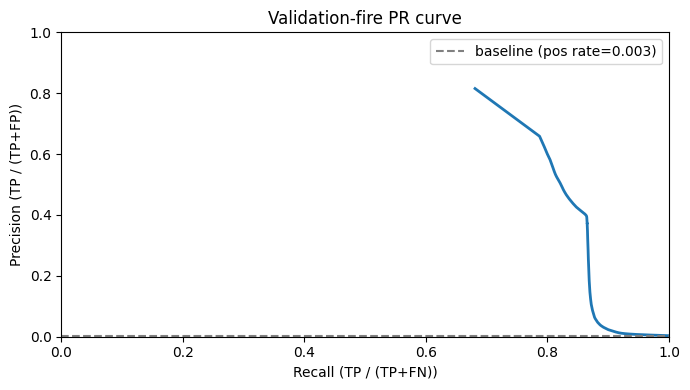

In [20]:
# Cell purpose:
# Select an operating threshold from validation fires using the shared NN helper module.

VALIDATION_FIRES = "auto"
VALIDATION_FRACTION_OF_TRAIN_FIRES = 0.30
VALIDATION_SPLIT_SEED = 123
VAL_PR_THRESHOLDS = np.linspace(0.0, 1.0, 1001)

val_pr_df = None
val_normalizer = None
val_training_artifacts = None
inner_train_entries = []
val_entries = []
val_best = None
val_baseline = None
VAL_TUNED_THRESHOLD = None

if RUN_PR_SECTION:
    inner_train_entries, val_entries = split_validation_fire_entries(
        train_fire_entries,
        VALIDATION_FIRES,
        VALIDATION_FRACTION_OF_TRAIN_FIRES,
        VALIDATION_SPLIT_SEED,
    )

    print("inner-train fires:", [entry["fire_name"] for entry in inner_train_entries])
    print("validation fires:", [entry["fire_name"] for entry in val_entries])

    val_normalizer = fit_zscore_normalizer(
        inner_train_entries,
        REPO_ROOT,
        feature_schema,
        POSITIVE_THRESHOLD,
        enabled=NORMALIZE_FEATURES,
        **ITERATION_KWARGS,
    )

    validation_training_config = MLPConfig(
        hidden_dims=tuple(HIDDEN_DIMS),
        dropout=DROPOUT,
        use_batchnorm=USE_BATCHNORM,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        seed=SEED,
    )

    val_training_artifacts = train_feedforward_network(
        inner_train_entries,
        REPO_ROOT,
        feature_schema,
        POSITIVE_THRESHOLD,
        val_normalizer,
        CLASSIFICATION_PROB_THRESHOLD,
        validation_training_config,
        device=DEFAULT_DEVICE,
        **ITERATION_KWARGS,
    )

    val_pr_result = compute_pr_curve(
        val_training_artifacts,
        val_entries,
        REPO_ROOT,
        feature_schema,
        POSITIVE_THRESHOLD,
        val_normalizer,
        VAL_PR_THRESHOLDS,
        **ITERATION_KWARGS,
    )
    val_pr_df = val_pr_result["df"]
    val_baseline = float(val_pr_result["baseline"])
    val_best_row = val_pr_result["best"]
    val_best = val_best_row.to_dict()
    VAL_TUNED_THRESHOLD = float(val_best_row["threshold"])

    print("validation positive rate (baseline precision at recall=1):", val_baseline)
    print("best threshold by F1:", VAL_TUNED_THRESHOLD)
    print("precision:", float(val_best_row["precision"]), "recall:", float(val_best_row["recall"]), "f1:", float(val_best_row["f1"]))

    val_plot_df = val_pr_df.sort_values("recall")

    plt.figure(figsize=(7, 4))
    plt.plot(val_plot_df["recall"], val_plot_df["precision"], linewidth=2)
    plt.hlines(val_baseline, 0, 1, linestyles="dashed", colors="gray", label=f"baseline (pos rate={val_baseline:.3f})")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Recall (TP / (TP+FN))")
    plt.ylabel("Precision (TP / (TP+FP))")
    plt.title("Validation-fire PR curve")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Skipped validation PR section.")


## 11A) Train-selected threshold applied to test split

This section intentionally performs the following experiment:

1. Sweep thresholds on **training fires** and select the best-F1 threshold.
2. Freeze that threshold.
3. Apply it directly to held-out test fires and report resulting metrics.

Use this as a transfer/sensitivity check for threshold stability.


In [21]:
# Cell purpose:
# Find the best-F1 threshold on training fires and transfer it to test fires.

train_selected_threshold = None
train_threshold_df = None
train_threshold_test_metrics = None

if RUN_PR_SECTION:
    if training_artifacts is None or not trained:
        raise RuntimeError("Train-threshold section requires training section to run first.")
    if not train_fire_entries or not test_fire_entries:
        raise RuntimeError("Train-threshold section requires both train and test fire entries.")

    TRAIN_PR_THRESHOLDS = np.linspace(0.0, 1.0, 1001)
    train_pr_result = compute_pr_curve(
        training_artifacts,
        train_fire_entries,
        REPO_ROOT,
        feature_schema,
        POSITIVE_THRESHOLD,
        normalizer,
        TRAIN_PR_THRESHOLDS,
        **ITERATION_KWARGS,
    )
    train_threshold_df = train_pr_result["df"].sort_values("f1", ascending=False).reset_index(drop=True)

    best_train = train_threshold_df.iloc[0]
    train_selected_threshold = float(best_train["threshold"])
    train_threshold_test_metrics = threshold_transfer_to_entries(
        training_artifacts,
        test_fire_entries,
        REPO_ROOT,
        feature_schema,
        POSITIVE_THRESHOLD,
        normalizer,
        train_selected_threshold,
        **ITERATION_KWARGS,
    )
else:
    print("Skipped train-threshold->test section.")


In [22]:
if train_threshold_df is not None and train_threshold_test_metrics is not None:
    print("best threshold by F1 on train fires:", train_selected_threshold)
    print("test metrics using train-selected threshold:", train_threshold_test_metrics)
    train_threshold_df.head(12)
else:
    print("Train-threshold transfer results are unavailable.")


best threshold by F1 on train fires: 1.0
test metrics using train-selected threshold: {'train_selected_threshold': 1.0, 'test_accuracy': 0.998435590941682, 'test_precision': 0.7843143092480673, 'test_recall': 0.6274003921599759, 'test_f1': 0.6971367581680898, 'test_tp': 79033, 'test_fp': 21734, 'test_fn': 46936, 'test_tn': 43747466}


## 11) Precision-Recall curve (test split)

This section sweeps probability thresholds on held-out test fires and reports PR/F1 behavior.

Because positives are rare, PR curves are often more informative than ROC here.

- Precision: `TP / (TP + FP)`
- Recall: `TP / (TP + FN)`
- F1: harmonic mean of precision and recall


test-fire positive rate (baseline precision at recall=1): 0.0028697691083043784
best threshold by F1: 0.999
precision: 0.6708559108059803 recall: 0.7508831537918059 f1: 0.7086172344689379


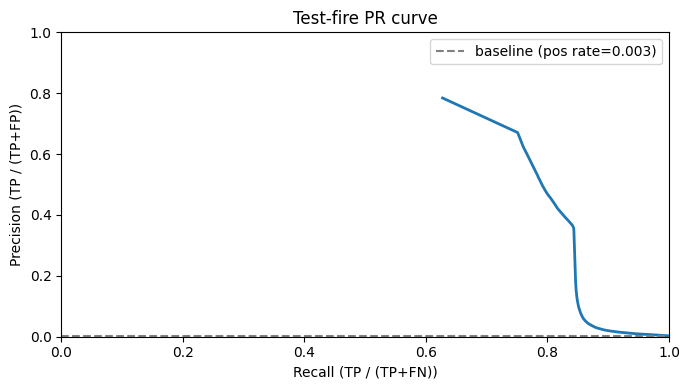

In [23]:
# Cell purpose:
# Sweep probability thresholds on test fires to build PR/F1 curves and top-threshold table.

pr_df = None
pr_best = None
test_pr_baseline = None

if RUN_PR_SECTION:
    if training_artifacts is None or not trained:
        raise RuntimeError("Precision-recall section requires training section to run first.")
    if not test_fire_entries:
        raise RuntimeError("Precision-recall section requires fire discovery section to be enabled.")

    PR_THRESHOLDS = np.linspace(0.0, 1.0, 1001)
    pr_result = compute_pr_curve(
        training_artifacts,
        test_fire_entries,
        REPO_ROOT,
        feature_schema,
        POSITIVE_THRESHOLD,
        normalizer,
        PR_THRESHOLDS,
        **ITERATION_KWARGS,
    )
    pr_df = pr_result["df"]

    best = pr_result["best"]
    pr_best = best.to_dict()
    test_pr_baseline = float(pr_result["baseline"])

    print("test-fire positive rate (baseline precision at recall=1):", test_pr_baseline)
    print("best threshold by F1:", float(best["threshold"]))
    print("precision:", float(best["precision"]), "recall:", float(best["recall"]), "f1:", float(best["f1"]))

    pr_plot_df = pr_df.sort_values("recall")

    plt.figure(figsize=(7, 4))
    plt.plot(pr_plot_df["recall"], pr_plot_df["precision"], linewidth=2)
    plt.hlines(test_pr_baseline, 0, 1, linestyles="dashed", colors="gray", label=f"baseline (pos rate={test_pr_baseline:.3f})")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Recall (TP / (TP+FN))")
    plt.ylabel("Precision (TP / (TP+FP))")
    plt.title("Test-fire PR curve")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("PR dataframe is unavailable.")


In [24]:
# Cell purpose:
# Display top-F1 thresholds (descending) and a quick head view of the full PR dataframe.

if pr_df is not None:
    pr_df.sort_values("f1", ascending=False).head(30)
else:
    print("PR dataframe is unavailable.")


## 12) Coefficients / interpretation placeholder

This notebook intentionally skips coefficient-style interpretation.

- The logistic baseline can inspect linear coefficients directly.
- This feed-forward neural network does not expose an equivalent coefficient table with the same meaning.
- To keep this notebook aligned with the logistic baseline, this section remains an explicit placeholder instead of adding a proxy feature-importance analysis.


In [25]:
# Cell purpose:
# Record a structured placeholder explaining why coefficient-style inspection is omitted.

model_interpretation_note = None

if RUN_COEFFICIENT_SECTION:
    model_interpretation_note = {
        "status": "omitted",
        "reason": "This feed-forward NN baseline does not expose logistic-style coefficients with directly comparable interpretation.",
        "recommended_comparison": "Use docs/neighbor_cell_confidence_regression.ipynb for coefficient inspection.",
    }
    model_interpretation_note
else:
    print("Skipped model interpretation placeholder section.")


In [26]:
# Cell purpose:
# Print the placeholder note so the omission is explicit in notebook outputs.

if RUN_COEFFICIENT_SECTION and model_interpretation_note is not None:
    print(model_interpretation_note["reason"])
else:
    print("Skipped model interpretation placeholder note.")


This feed-forward NN baseline does not expose logistic-style coefficients with directly comparable interpretation.


## 13) JSON-style report object

This section consolidates run configuration, split metadata, class balance, model configuration, training history, and evaluation metrics into one dictionary (`report`).

It is intended to be easy to serialize or export to downstream analysis tools.


In [27]:
# Cell purpose:
# Construct a JSON-like report dictionary aggregating configuration + results and save it to disk.

report = None
report_path = None

if RUN_REPORT_SECTION:
    report = build_nn_report(
        fire_entries=fire_entries,
        train_fire_entries=train_fire_entries,
        test_fire_entries=test_fire_entries,
        val_fire_entries=val_entries,
        feature_schema=feature_schema,
        positive_threshold=POSITIVE_THRESHOLD,
        classification_prob_threshold=CLASSIFICATION_PROB_THRESHOLD,
        fire_train_fraction=FIRE_TRAIN_FRACTION,
        fire_split_seed=FIRE_SPLIT_SEED,
        normalizer=normalizer,
        dataset_stats=dataset_stats,
        metrics_test=metrics_test,
        training_artifacts=training_artifacts,
        discounted_rain_lookback_hours=DISCOUNTED_RAIN_LOOKBACK_HOURS,
        discounted_rain_half_life_days=DISCOUNTED_RAIN_HALF_LIFE_DAYS,
        validation_threshold_df=val_pr_df,
        validation_threshold_best=val_best,
        validation_threshold_value=VAL_TUNED_THRESHOLD,
        train_threshold_test_metrics=train_threshold_test_metrics,
        test_pr_df=pr_df,
        test_pr_best=pr_best,
        test_pr_baseline=test_pr_baseline,
    )
    if model_interpretation_note is not None:
        report["model_interpretation"] = model_interpretation_note

    out_dir = REPO_ROOT / "data" / "analysis" / "mlp_fire_holdout"
    out_dir.mkdir(parents=True, exist_ok=True)
    report_path = out_dir / "report.json"
    with report_path.open("w", encoding="utf-8") as report_file:
        json.dump(report, report_file, indent=2)

    print("saved:", report_path)
    print("Report keys:", list(report.keys()))
else:
    print("Skipped report section.")


saved: /Users/seanmay/Desktop/Current Projects/wildfire-prediction/data/analysis/mlp_fire_holdout/report.json
Report keys: ['model', 'target', 'fires_used', 'train_fires', 'test_fires', 'validation_fires', 'thresholds', 'split', 'feature_order', 'feature_engineering', 'feature_normalization', 'metrics_test', 'class_balance', 'training', 'validation_threshold_selection', 'train_threshold_transfer', 'test_pr_curve', 'data', 'model_interpretation']


## 14) Save checkpoint

In [ ]:
import torch
from dataclasses import asdict

ckpt_dir = REPO_ROOT / "data" / "checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)

if training_artifacts is not None:
    checkpoint = {
        "model_state_dict": training_artifacts.model.state_dict(),
        "normalizer_mean": normalizer.mean.tolist(),
        "normalizer_std": normalizer.std_safe.tolist(),
        "include_discounted_rain": INCLUDE_DISCOUNTED_RAIN_FEATURE,
        "config": asdict(training_artifacts.config),
        "train_fires": [e["fire_name"] for e in train_fire_entries],
        "test_fires": [e["fire_name"] for e in test_fire_entries],
    }
    torch.save(checkpoint, ckpt_dir / "mlp.pt")
    print(f"Saved checkpoint to {ckpt_dir / 'mlp.pt'}")
else:
    print("Skipped checkpoint save (no training artifacts).")

## 14) Notes and constraints

- Split is by full fires, not random rows, to avoid within-fire leakage.
- Feature normalization (when enabled) is train-only.
- Discounted rain uses a causal RTMA history window ending before the prediction hour.
- Threshold outputs can vary meaningfully with class imbalance and split composition.
- Runtime can still be substantial because this processes all available pixel-hour samples.
- Core preprocessing logic lives in `scripts/neighbor_cell_logreg.py`, with NN-specific training/evaluation in `scripts/neighbor_cell_nn.py`.
- Section 12 is intentionally a placeholder so this notebook stays aligned with the logistic baseline without implying coefficient-style interpretability.
